In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("emails.csv")

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (5172, 3002)
  Email No.  the  to  ect  and  for  of    a  you  hou  ...  connevey  jay  \
0   Email 1    0   0    1    0    0   0    2    0    0  ...         0    0   
1   Email 2    8  13   24    6    6   2  102    1   27  ...         0    0   
2   Email 3    0   0    1    0    0   0    8    0    0  ...         0    0   
3   Email 4    0   5   22    0    5   1   51    2   10  ...         0    0   
4   Email 5    7   6   17    1    5   2   57    0    9  ...         0    0   

   valued  lay  infrastructure  military  allowing  ff  dry  Prediction  
0       0    0               0         0         0   0    0           0  
1       0    0               0         0         0   1    0           0  
2       0    0               0         0         0   0    0           0  
3       0    0               0         0         0   0    0           0  
4       0    0               0         0         0   1    0           0  

[5 rows x 3002 columns]


In [ ]:
# All columns except last = features
# Last column = label
X = df.iloc[:, 1:-1]
y = df.iloc[:, -1]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [8]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

In [9]:
svm = SVC(kernel='linear')
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

In [10]:
acc_knn = accuracy_score(y_test, knn_pred)
acc_svm = accuracy_score(y_test, svm_pred)

print("\nKNN Accuracy:", acc_knn)
print("SVM Accuracy:", acc_svm)

print("\nSVM Classification Report:\n")
print(classification_report(y_test, svm_pred))


KNN Accuracy: 0.8628019323671497
SVM Accuracy: 0.9594202898550724

SVM Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.97      0.97       739
           1       0.92      0.94      0.93       296

    accuracy                           0.96      1035
   macro avg       0.95      0.95      0.95      1035
weighted avg       0.96      0.96      0.96      1035



In [11]:
if acc_svm > acc_knn:
    print("\nSVM performs better")
else:
    print("\nKNN performs better")



SVM performs better


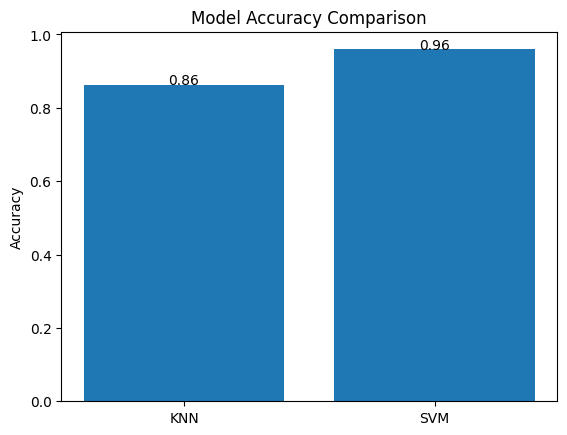

In [12]:
models = ['KNN', 'SVM']
accuracy = [acc_knn, acc_svm]

plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

# Add values on bars
for i, v in enumerate(accuracy):
    plt.text(i, v, f"{v:.2f}", ha='center')

plt.show()